# Notebook 3 — 2D Consolidation FEM

Runs the 2D FEM consolidation solver with the same two-layer configuration used in Notebook 2.
Results are extracted at the centreline (x = 0), directly beneath the centre of the strip load:

1. **Pore-pressure profiles** — vertical profiles of excess pore pressure at t = 30 and 365 days.
2. **Darcy flux profiles** — vertical component q = -(k/gw) du/dz along the centreline at the same times.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import seaborn as sns

import os, sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

from src.geotech_consolidation.models.terzaghi_2d.fem import Get_terzaghi2D_FEA


sns.set_theme(style="whitegrid")


H = 5.0
W = H
nx = 100
load = 100.0
base = 2.0
final_time = 365 * (24 * 60 * 60)   # (s)
time_steps = 1000
time_days  = np.linspace(0, final_time / (24 * 3600), time_steps)
gamma_w    = 9.81


depths  = [2.5, 5.0]
Cv      = [5e-7, 7e-8]
Mv      = [5e-4, 5e-4]

k_list  = [Cv[i] * Mv[i] * gamma_w for i in range(2)]

print(f"k1 = {k_list[0]:.3e} m/s,  k2 = {k_list[1]:.3e} m/s,  interface at z = {depths[0]} m")

k1 = 2.453e-09 m/s,  k2 = 3.434e-10 m/s,  interface at z = 2.5 m


## FEM Solve

In [2]:
settlement_surface, total_settlement, u_hist, unique_X, node_X, node_Y = Get_terzaghi2D_FEA(
    H=H, W=W, nx=nx, load=load,
    final_time=final_time, time_steps=time_steps,
    Cv=Cv, Mv=Mv,
    base=base, depths=depths
)

print(f"u_hist shape:       {u_hist.shape}   (time_steps x n_nodes)")
print(f"Max pore pressure:  {u_hist.max():.2f} kPa")
print(f"Max settlement:     {settlement_surface.max() * 1000:.2f} mm")

u_hist shape:       (1000, 10201)   (time_steps x n_nodes)
Max pore pressure:  99.99 kPa
Max settlement:     117.08 mm


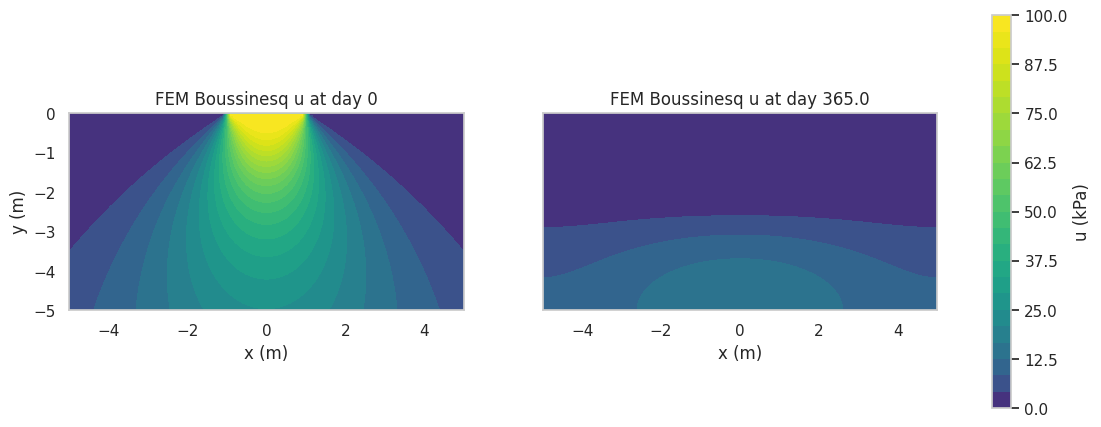

In [3]:
import matplotlib.colors as mcolors
u0_fem = u_hist[0, :]
ufinal_fem = u_hist[-1, :]
vmin = 0.0
vmax = u0_fem.max()
norm = mcolors.PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax)
levels = np.linspace(vmin, vmax, 25)

triang = tri.Triangulation(node_X, node_Y)

final_day = final_time / (60**2 * 24)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

cf0 = axes[0].tricontourf(triang, u0_fem, levels=levels, cmap="viridis", norm=norm)
axes[0].set_title("FEM Boussinesq u at day 0")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_aspect("equal")

cf1 = axes[1].tricontourf(triang, ufinal_fem, levels=levels, cmap="viridis", norm=norm)
axes[1].set_title(f"FEM Boussinesq u at day {final_day:.1f}")
axes[1].set_xlabel("x (m)")
axes[1].set_aspect("equal")

# One shared colourbar
cbar = fig.colorbar(cf1, ax=axes, label="u (kPa)", shrink=0.85)

plt.show()

## Surface Settlement Profile
Settlement across the surface width at several times.

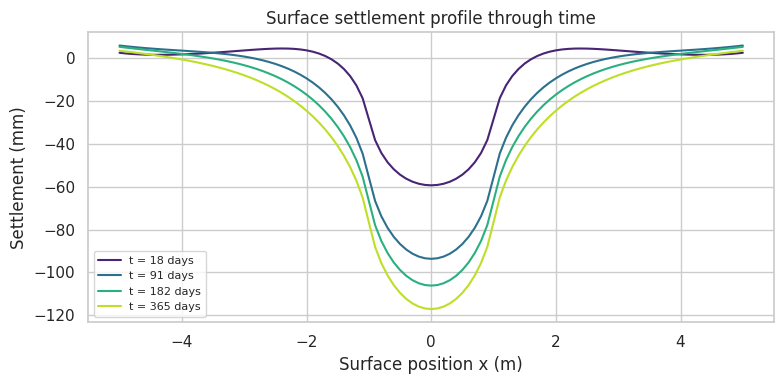

In [4]:
fracs   = [0.05, 0.25, 0.5, 1.0]
colours = plt.cm.viridis(np.linspace(0.1, 0.9, len(fracs)))

fig, ax = plt.subplots(figsize=(8, 4))
for col, frac in zip(colours, fracs):
    ti    = int(frac * (time_steps - 1))
    label = f"t = {time_days[ti]:.0f} days"
    ax.plot(unique_X, -settlement_surface[ti, :] * 1000, color=col, label=label)

ax.set_xlabel("Surface position x (m)")
ax.set_ylabel("Settlement (mm)")
ax.set_title("Surface settlement profile through time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Pore-Pressure Continuity & Darcy Flux — Centreline (x = 0)

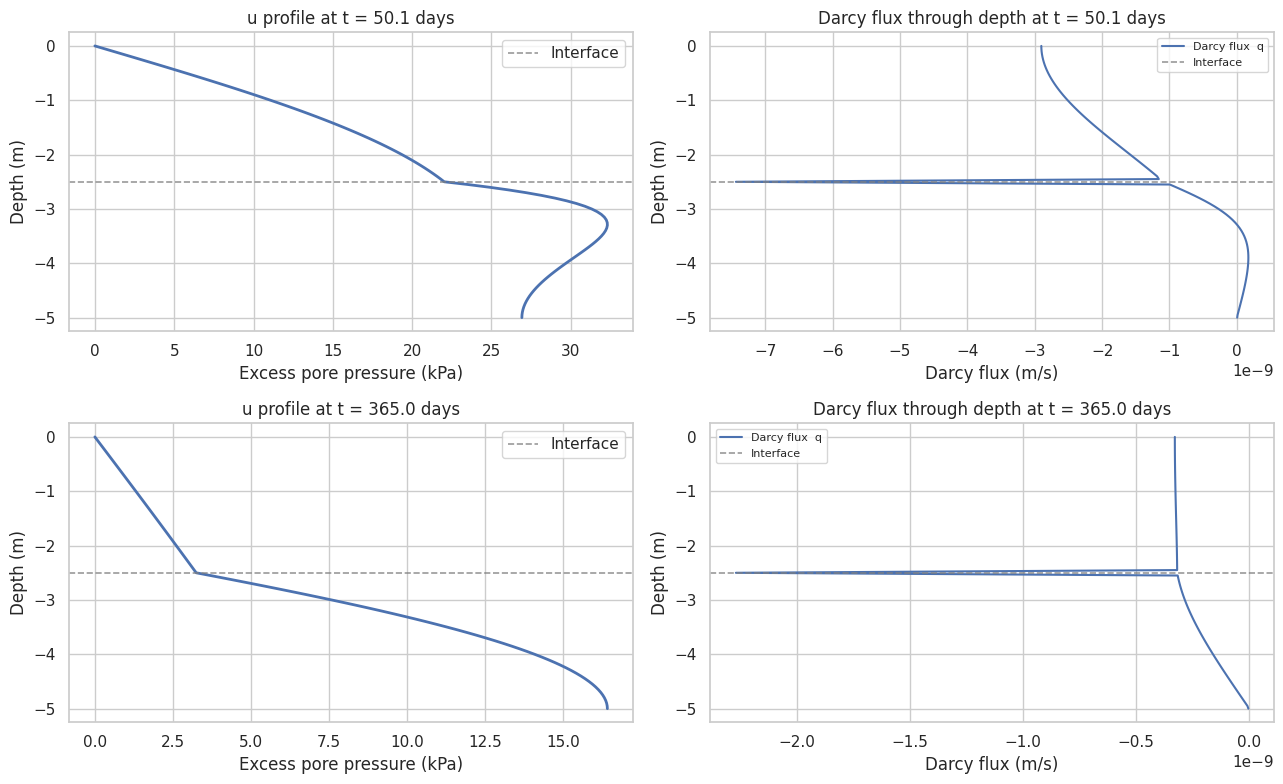

In [7]:
x_cl     = unique_X[np.argmin(np.abs(unique_X))]
spacings = np.diff(unique_X)
dx_min   = spacings[spacings > 1e-9].min()   # ignore numerical duplicates
dx_half  = 0.5 * dx_min
cl_mask  = np.abs(node_X - x_cl) < dx_half
cl_idx   = np.where(cl_mask)[0]
cl_sort  = np.argsort(node_Y[cl_idx])[::-1]
cl_nodes = cl_idx[cl_sort]
cl_y     = node_Y[cl_nodes]      # y: 0 (surface) to -H (base)
cl_depth = -cl_y                 # positive depth: 0 to H

interface_depth = depths[0]      # 2.5 m
k_cl = np.where(cl_depth <= interface_depth, k_list[0], k_list[1])

check_days = [50.0, 365.0]

fig, axes = plt.subplots(len(check_days), 2, figsize=(13, 4 * len(check_days)), squeeze=False)

for row, target_day in enumerate(check_days):
    t_check = int(np.argmin(np.abs(time_days - target_day)))                                                                         
    u_t     = u_hist[t_check, cl_nodes]

    axes[row, 0].plot(u_t, cl_y, linewidth=2)
    axes[row, 0].axhline(-interface_depth, color="grey", linestyle="--",
                         linewidth=1.2, alpha=0.8, label="Interface")
    axes[row, 0].set_xlabel("Excess pore pressure (kPa)")
    axes[row, 0].set_ylabel("Depth (m)")
    axes[row, 0].set_title(f"u profile at t = {time_days[t_check]:.1f} days")
    axes[row, 0].legend()

    # One-sided gradients on each side of the interface (flux continuity, k discontinuous)
    above = cl_depth <  interface_depth
    below = cl_depth >= interface_depth

    grad = np.empty_like(u_t)
    grad[above] = np.gradient(u_t[above], cl_depth[above])
    grad[below] = np.gradient(u_t[below], cl_depth[below])

    darcy_flux = -(k_cl / gamma_w) * grad

    axes[row, 1].plot(darcy_flux, cl_y, label="Darcy flux  q")
    axes[row, 1].axhline(-interface_depth, color="grey", linestyle="--",
                         linewidth=1.2, alpha=0.8, label="Interface")
    axes[row, 1].set_xlabel("Darcy flux (m/s)")
    axes[row, 1].set_ylabel("Depth (m)")
    axes[row, 1].set_title(f"Darcy flux through depth at t = {time_days[t_check]:.1f} days")
    axes[row, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()